In [1]:
!pip install -qq openai-clip
# !pip install -qq torch
# !pip install -qq faiss-gpu-cu11==1.10.0
# !pip install -qq numpy==1.23.5
!pip install faiss-gpu-cu12

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 21.3 MB/s eta 0:00:00a 0:00:01
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.4/48.4 MB 34.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 581.2/581.2 MB 2.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 71.4 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.6/89.6 MB 18.2 MB/s eta 0:00:00:00:0100:01


In [2]:
import clip
import torch
import faiss
import json
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from peft import PeftModel
import faiss
from tqdm import tqdm
from glob import glob

from google.colab import files

# Config

In [3]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
# ROOT_DIR = '/content/drive/MyDrive/Mushroom_Dataset/Dataset'
ADAPTER_PATH = '/kaggle/input/datasets/sandaria/mushroom/Clip_LoRA_pretrained (2)/Clip_LoRA_pretrained/clip_text_lora_adapter'
INDEX_PATH = '/kaggle/input/datasets/sandaria/mushroom/Clip_LoRA_pretrained (2)/Clip_LoRA_pretrained/vector_finetuned.index'
INDEX_PATHS_FILE = INDEX_PATH + '.paths'

# Load fine-tune CLIP model

In [4]:
base_model, preprocess = clip.load("ViT-B/32", device=device)
model = PeftModel.from_pretrained(base_model, ADAPTER_PATH).to(device)
model.eval()

100%|████████████████████████████████████████| 338M/338M [00:02<00:00, 169MiB/s]


PeftModelForFeatureExtraction(
  (base_model): LoraModel(
    (model): CLIP(
      (visual): VisionTransformer(
        (conv1): Conv2d(3, 768, kernel_size=(32, 32), stride=(32, 32), bias=False)
        (ln_pre): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (transformer): Transformer(
          (resblocks): Sequential(
            (0): ResidualAttentionBlock(
              (attn): MultiheadAttention(
                (out_proj): lora.Linear(
                  (base_layer): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
                  (lora_dropout): ModuleDict(
                    (default): Dropout(p=0.05, inplace=False)
                  )
                  (lora_A): ModuleDict(
                    (default): Linear(in_features=768, out_features=16, bias=False)
                  )
                  (lora_B): ModuleDict(
                    (default): Linear(in_features=16, out_features=768, bias=False)
                  )
            

# Build Faiss Index (If you haven't built before)

In [5]:
# # Tạo embedding cho tất cả ảnh trong dataset

# def generate_clip_embeddings(root_dir, model, batch_size=32):
#     # lấy đường dẫn toàn bộ ảnh trong dataset
#     image_paths = []
#     for ext in ['.jpg', '.jpeg', '.png', '.bmp']:
#         image_paths.extend(glob(os.path.join(root_dir, '**/*' + ext), recursive=True))

#     embeddings = []
#     model.eval()

#     # tạo embedding cho ảnh: lấy ảnh ra theo đường dẫn ảnh, preprocess theo clip rồi .encode_image để lấy embedding ảnh
#     with torch.no_grad():
#         for i in tqdm(range(0, len(image_paths), batch_size), desc="Generating embeddings"):
#             batch_paths = image_paths[i:i+batch_size]
#             images = []

#             for img_path in batch_paths:
#                 try:
#                     img = preprocess(Image.open(img_path).convert("RGB"))
#                     images.append(img)
#                 except:
#                     print(f"Error loading {img_path}")
#                     continue

#             if images:
#                 images = torch.stack(images).to(device)
#                 img_emb = model.encode_image(images)
#                 img_emb = F.normalize(img_emb, dim=-1)  # Normalize để dùng cosine similarity
#                 embeddings.append(img_emb.cpu().numpy())

#     embeddings = np.vstack(embeddings)
#     return embeddings, image_paths

In [6]:
# # Tạo faiss để truy vấn nhanh hơn

# def create_faiss_index(embeddings, image_paths, output_path):
#     dimension = embeddings.shape[1]  #lấy số chiều embeddings

#     # Dùng IndexFlatIP vì embeddings đã được normalize
#     # tích vô hướng của normalize vectors = cosine similarity
#     index = faiss.IndexFlatIP(dimension)    #IP: Inner Product: tích vô hướng
#     index.add(embeddings.astype('float32'))

#     faiss.write_index(index, output_path)
#     with open(output_path + '.paths', 'w') as f:
#         json.dump(image_paths, f)

#     print(f"lưu faiss index vào {output_path}")
#     return index

In [7]:
# import os
# import torch.nn.functional as F

# OUTPUT_INDEX_PATH_FINE = '/content/drive/MyDrive/Mushroom_Dataset/Clip_LoRA_pretrained/vector_finetuned.index'
# embeddings, image_paths_index = generate_clip_embeddings(ROOT_DIR, model, batch_size=32)
# index = create_faiss_index(embeddings, image_paths_index, OUTPUT_INDEX_PATH_FINE)

# Load Faiss Index

In [8]:
index = faiss.read_index(INDEX_PATH)
with open(INDEX_PATHS_FILE, 'r') as f:
    image_paths = json.load(f)

print("Load thanhf coong")

Load thanhf coong


# Visualize

In [9]:
import os

def visualize_results(query, retrieved_images, scores, num_display=5, is_image_query=False):
    num_display = min(num_display, len(retrieved_images))
    # fig, axes = plt.subplots(1, num_display + int(is_image_query), figsize=(4*(num_display + int(is_image_query)), 4))
    if is_image_query:
        fig, axes = plt.subplots(2, num_display, figsize=(4 * num_display, 8))
        #hiện ảnh truy vấn
        img_q = query if isinstance(query, Image.Image) else Image.open(query)
        axes[0, 0].imshow(img_q)
        axes[0, 0].axis('off')
        axes[0, 0].set_title('Query Image', fontsize=12, fontweight='bold', loc='left')
        
        #ẩn ô trống ở hàng 1
        for j in range(1, num_display):
            axes[0, j].axis('off')
            
        # hiển thị ảnh kết quả ở hàng 2
        for i, (img_path, score) in enumerate(zip(retrieved_images[:num_display], scores[:num_display])):
            img = Image.open(img_path)

            mushroom_name = "_".join(os.path.basename(os.path.dirname(os.path.dirname(img_path))).split("_")[1:])
            
            axes[1, i].imshow(img)
            axes[1, i].axis('off')
            axes[1, i].set_title(f'Rank {i+1}\n{mushroom_name}\nScore: {score:.3f}', fontsize=10)
            
    else:
        fig, axes = plt.subplots(1, num_display, figsize=(4 * num_display, 4))
        if num_display == 1: axes = [axes]
        
        for i, (img_path, score) in enumerate(zip(retrieved_images[:num_display], scores[:num_display])):
            img = Image.open(img_path)
            mushroom_name = "_".join(os.path.basename(os.path.dirname(os.path.dirname(img_path))).split("_")[1:])
            axes[i].imshow(img)
            axes[i].axis('off')
            axes[i].set_title(f'Rank {i+1}\n{mushroom_name}\n{score:.3f}', fontsize=10)

    plt.tight_layout()
    plt.show()

# Retrieve images by text query

In [10]:
import torch.nn.functional as F

def retrieve_similar_images_by_text(query_text, model, index, image_paths, top_k=5):
    model.eval()
    with torch.no_grad():
        text_tokens = clip.tokenize([query_text], context_length=77, truncate=True).to(device)
        text_emb = model.encode_text(text_tokens)
        text_emb = F.normalize(text_emb, dim=-1)
        text_emb = text_emb.cpu().numpy()

    scores, indices = index.search(text_emb.astype('float32'), top_k)
    #fix file part, old code, i dont want faiss indexing again
    old_prefix = "/kaggle/input"
    new_prefix = "/kaggle/input/datasets/sandaria"
    
    # retrieved_images = [image_paths[idx] for idx in indices[0]]
    retrieved_images = [image_paths[idx].replace(old_prefix, new_prefix) for idx in indices[0]]
    cosine_scores = scores[0]

    return retrieved_images, cosine_scores

Query Text: A red poisonous mushroom with white dots


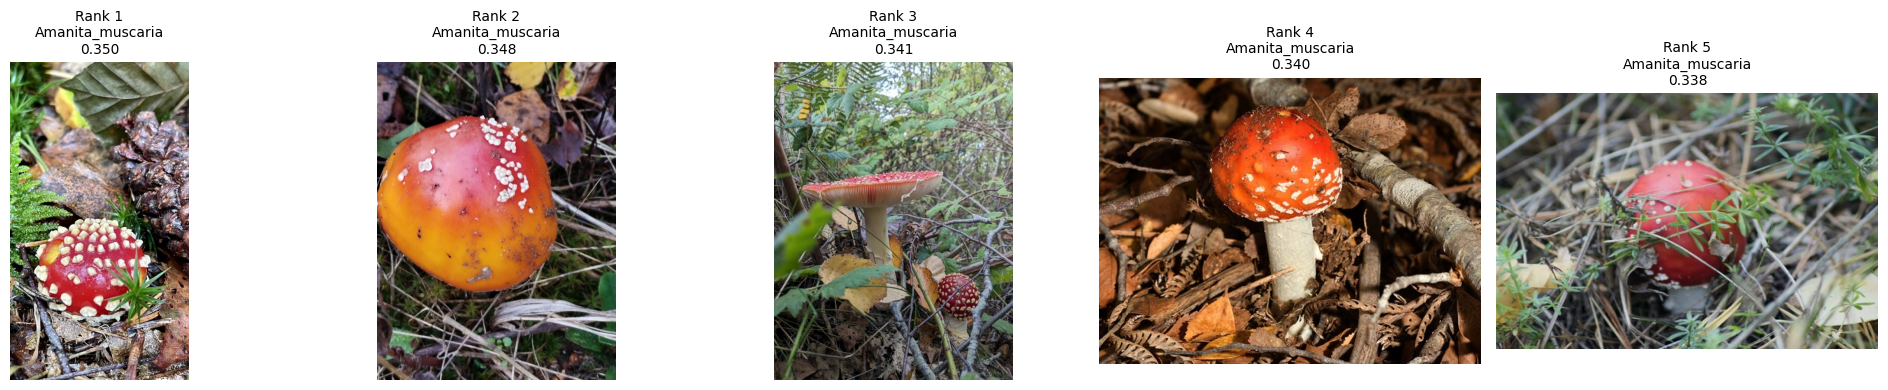

/kaggle/input/datasets/sandaria/mushroom/Dataset/Dataset/23_Amanita_muscaria/Images/50.jpg
/kaggle/input/datasets/sandaria/mushroom/Dataset/Dataset/23_Amanita_muscaria/Images/58.jpg
/kaggle/input/datasets/sandaria/mushroom/Dataset/Dataset/23_Amanita_muscaria/Images/12.jpg
/kaggle/input/datasets/sandaria/mushroom/Dataset/Dataset/23_Amanita_muscaria/Images/03.jpg
/kaggle/input/datasets/sandaria/mushroom/Dataset/Dataset/23_Amanita_muscaria/Images/65.jpg


In [11]:
query_text = "A red poisonous mushroom with white dots"
retrieved_images, scores = retrieve_similar_images_by_text(query_text, model, index, image_paths, top_k=5)

print(f"Query Text: {query_text}")
visualize_results(query_text, retrieved_images, scores, num_display=5)

for image_path in retrieved_images:
    print(image_path)   


# Retrieve similar images by image

In [12]:
def retrieve_similar_images_by_image(image_path, model, index, image_paths, top_k=5):
    model.eval()
    with torch.no_grad():
        img = preprocess(Image.open(image_path).convert("RGB")).unsqueeze(0).to(device)
        img_emb = model.encode_image(img)
        img_emb = F.normalize(img_emb, dim=-1)
        img_emb = img_emb.cpu().numpy()

    scores, indices = index.search(img_emb.astype('float32'), top_k)
    #fix path
    old_prefix = "/kaggle/input"
    new_prefix = "/kaggle/input/datasets/sandaria"
    
    retrieved_images = [image_paths[idx].replace(old_prefix, new_prefix) for idx in indices[0]]
    cosine_scores = scores[0]

    return retrieved_images, cosine_scores

Image Query Path: /kaggle/input/datasets/sandaria/mushroom/Dataset/Dataset/01_Volvariella_volvacea/Images/image_10.jpg


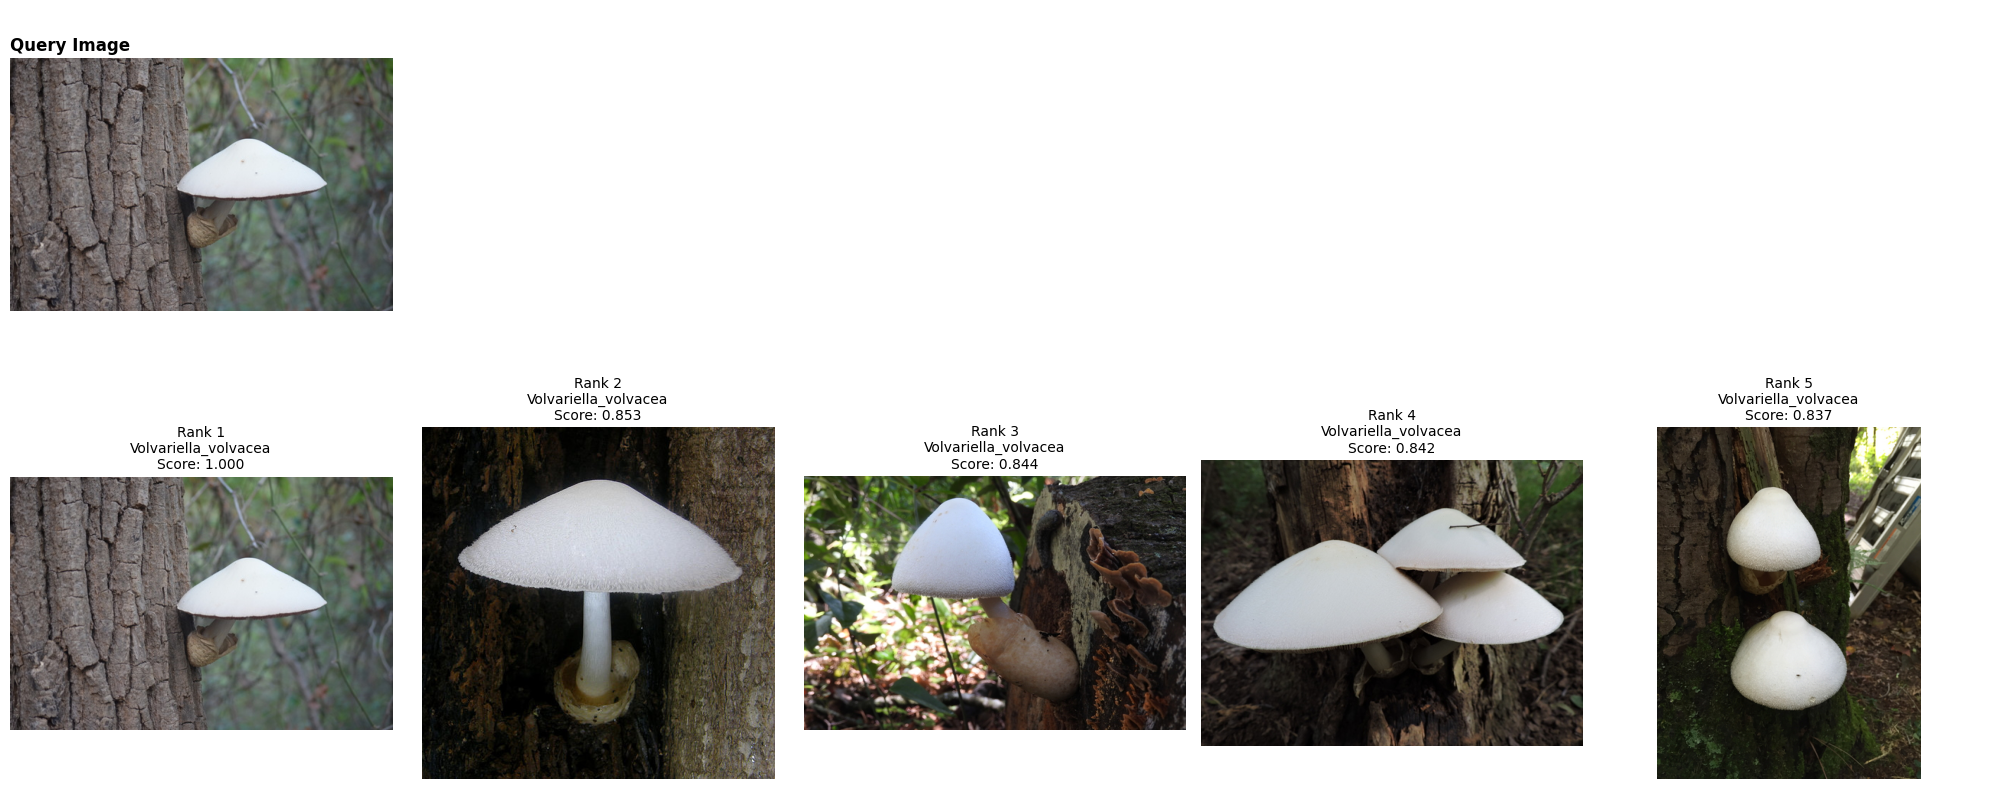

/kaggle/input/datasets/sandaria/mushroom/Dataset/Dataset/01_Volvariella_volvacea/Images/image_10.jpg
/kaggle/input/datasets/sandaria/mushroom/Dataset/Dataset/01_Volvariella_volvacea/Images/image_67.jpg
/kaggle/input/datasets/sandaria/mushroom/Dataset/Dataset/01_Volvariella_volvacea/Images/image_111.jpg
/kaggle/input/datasets/sandaria/mushroom/Dataset/Dataset/01_Volvariella_volvacea/Images/image_8.jpg
/kaggle/input/datasets/sandaria/mushroom/Dataset/Dataset/01_Volvariella_volvacea/Images/image_32.jpg


In [13]:
# ví dụ
image_path = '/kaggle/input/datasets/sandaria/mushroom/Dataset/Dataset/01_Volvariella_volvacea/Images/image_10.jpg'
print(f"Image Query Path: {image_path}")
retrieved_images, scores = retrieve_similar_images_by_image(image_path, model, index, image_paths, top_k=5)
visualize_results(image_path, retrieved_images, scores, num_display=5, is_image_query=True)

for image_path in retrieved_images:
    print(image_path)   # danh sach duogn dan anh
